## EN3160 Assignment 2 on Fitting and Alignment

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

### Q1

In [24]:
#Import image
im =cv.imread('the_berry_farms_sunflower_field.jpeg', cv.IMREAD_REDUCED_COLOR_4)
assert im is not None

# Get normalized grayscale image
gray = cv.cvtColor(im, cv.COLOR_BGR2GRAY) / 255

Radius: 11.46 pixels
Sigma: 8.100000000000007
Range of σ used: 1.0 to 9.900000000000007


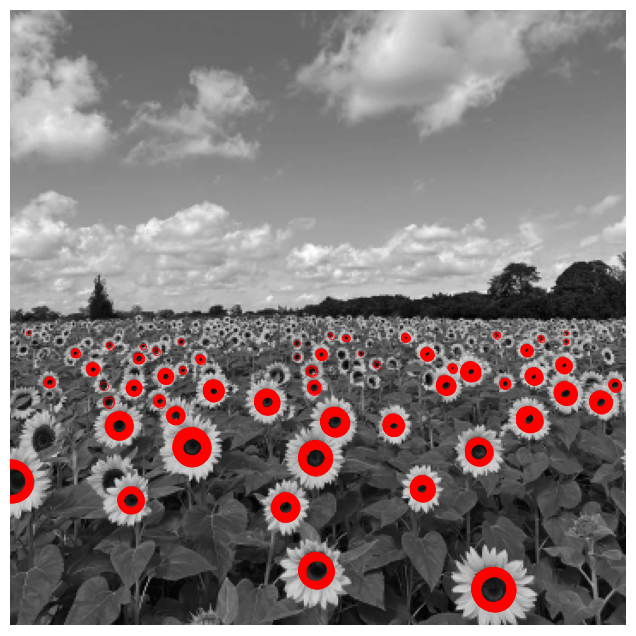

In [ ]:
# Plot the grayscale image
plt.figure(figsize=(8, 8), frameon=False)
plt.imshow(gray, cmap='gray')
plt.axis('off')

# Get the current axes object
ax = plt.gca()

# Store detected circles
detected_circles = []

# Range of Sigmas
sigmas = np.arange(1, 10, 0.1)

# Detect blobs at different sigmas
for sigma in sigmas:
    log_hw = 3*np.max(sigma)
    X, Y = np.meshgrid(np.arange(-log_hw, log_hw + 1, 1), np.arange(-log_hw, log_hw + 1, 1))

    # Get Laplacian of Gaussian
    log = (1/(2*np.pi*sigma**2)) * ((X**2 + Y**2 - 2*sigma**2) / sigma**4) * np.exp(-(X**2 + Y**2) / (2*sigma**2))
    
    # Scale Normalized Laplacian of Gaussian
    log = sigma**2 * log

    # Convolve image with LoG filter
    im_log = cv.filter2D(gray, -1, log)

    # Squared response to enhance blobs
    im_log = im_log**2

    coordinates = []
    h, w = im_log.shape
    # Threshold for maxima detection
    threshold = 0.1  
    # iterate over 3x3 sections of the image
    for i in range(1, h - 1):
        for j in range(1, w - 1):
            slice_img = im_log[i - 1:i + 2, j - 1:j + 2]
            if np.max(slice_img) >= threshold:
                # Get coordinates of the maximum point
                x, y = np.unravel_index(slice_img.argmax(), slice_img.shape)
                coordinates.append((i - 1 + x, j - 1 + y))
    coordinates = set(coordinates)

    # Plot circles around detected blobs
    for x, y in coordinates:
        radius = sigma * np.sqrt(2)
        detected_circles.append((x, y, radius, sigma))
        c = plt.Circle((y, x), radius, color='r', linewidth=0.5, fill=False)
        ax.add_patch(c)
    ax.plot()

# Parameters of the largest circles
if detected_circles:
    largest_circles = max(detected_circles, key=lambda c: c[2])
    x, y, radius, sigma = largest_circles
    print(f"Radius: {radius:.2f} pixels")
    print(f"Sigma: {sigma}")
    print(f"Range of σ used: {sigmas[0]} to {sigmas[-1]}")

ax.set_xlim([0, im.shape[1]])
ax.set_ylim([im.shape[0], 0])

plt.show()

### Q2

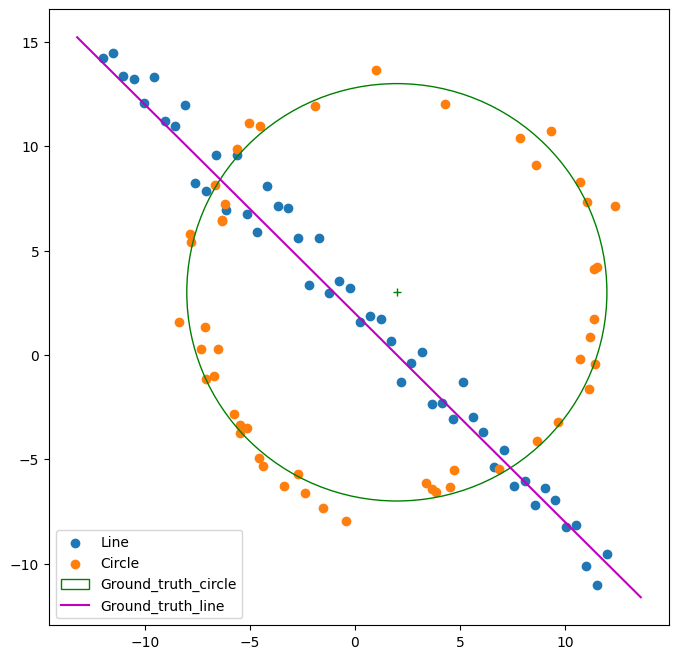

In [27]:
from scipy.optimize import minimize
from scipy import linalg
import matplotlib.pyplot as plt
import numpy as np
#import tikzplotlib

np.random.seed(0)
N = 100
half_n = N//2

r = 10
x0_gt, y0_gt = 2, 3  # Center
s = r/16
t = np.random.uniform(0, 2*np.pi, half_n)
n = s*np.random.randn(half_n)
x, y = x0_gt + (r + n)*np.cos(t), y0_gt + (r + n)*np.sin(t)
X_circ = np.hstack((x.reshape(half_n,1), y.reshape(half_n,1)))
s = 1.
m, b = -1, 2
x = np.linspace(-12, 12, half_n)
y = m*x + b + s*np.random.randn(half_n)
X_line = np.hstack((x.reshape(half_n,1), y.reshape(half_n,1)))
X = np.vstack((X_circ, X_line))  # All points

fig, ax = plt.subplots(1,1, figsize=(8,8))
ax.scatter(X_line[:,0], X_line[:,1], label='Line')
ax.scatter(X_circ[:,0], X_circ[:,1], label='Circle')
circle_gt = plt.Circle((x0_gt,y0_gt), r, color='g', fill=False, label='Ground_truth_circle')
ax.add_patch(circle_gt)
ax.plot((x0_gt), (y0_gt), '+', color='g')
x_min, x_max = ax.get_xlim()
x_ = np.array([x_min, x_max])
y_ = m*x_ + b
plt.plot(x_, y_, color='m', label='Ground_truth_line')
plt.legend()

### Part (a)

In [220]:
import math

def line_equation(x1, y1, x2, y2):
    # Calculate the direction vectors
    del_x = x2 - x1
    del_y = y2 - y1
    
    # Calculate the normalized vector (a, b)
    norm = math.sqrt(del_x**2 + del_y**2)
    if norm == 0:
        return None, None, None
    a = del_y / norm
    b = -del_x / norm

    # Calculate d
    d = (a * x1) + (b * y1)

    return a, b, d

# Total Least Squares fitting of a line to Optimize
def tls_line(x, indices):
    a, b, d = x[0], x[1], x[2]
    return np.sum(np.square(a*X[indices,0] + b*X[indices,1] - d))

# Constraint
def g(x):
    return x[0]**2 + x[1]**2 - 1

cons = ({'type': 'eq', 'fun': g})

# Computing the consensus (inliers)
def consensus(X, x, t):
    a, b, d = x[0], x[1], x[2]
    error = np.abs(a*X[:,0] + b*X[:,1] - d)
    return error < t

# Define RANSAC algorithm for line fitting
def ransac_line(X, max_iterations=1000, threshold=0.69, min_inliers=0.36*N):
    best_inliers = []
    best_model_line = []     # Best model normal (a, b) and distance from origin d
    best_error = np.inf
    best_sample = []    # Two samples leading to the best model computation

    for _ in range(max_iterations):
        
        # Randomly sample 2 points
        indices = np.random.choice(N, 2, replace=False)
        (x1, y1), (x2, y2) = X[indices,:]

        # Get line parameters
        x = line_equation(x1, y1, x2, y2)
        if x[0] is None and x[1] is None and x[2] is None:
            continue

        # Identify inliers
        inliers = consensus(X, x, threshold)

        # Use TLS fitting for above par models
        if inliers.sum() >= min_inliers:
            
            # Computing the new model using the inliers
            res = minimize(fun = tls_line, args = inliers, x0 = x, tol= 1e-6, constraints=cons, options={'disp': True})
            print(res.x, res.fun)
            
            if res.fun < best_error:
                print('A better model found ... ', res.x, res.fun)
                best_model_line = res.x
                best_error = res.fun
                best_inliers = inliers
                best_sample = X[indices,:]

    return best_model_line, best_inliers, best_sample




In [221]:
# Apply RANSAC to fit the line
best_model_line, best_inliers_line, best_sample_line = ransac_line(X)
print('Best line model', best_model_line)
print('Best sample', best_sample_line)

Optimization terminated successfully    (Exit mode 0)
            Current function value: 5.735430517073053
            Iterations: 4
            Function evaluations: 23
            Gradient evaluations: 4
[0.71440012 0.69973743 1.45673541] 5.735430517073053
A better model found ...  [0.71440012 0.69973743 1.45673541] 5.735430517073053
Optimization terminated successfully    (Exit mode 0)
            Current function value: 5.735430517072803
            Iterations: 4
            Function evaluations: 23
            Gradient evaluations: 4
[-0.71440012 -0.69973743 -1.45673542] 5.735430517072803
A better model found ...  [-0.71440012 -0.69973743 -1.45673542] 5.735430517072803
Optimization terminated successfully    (Exit mode 0)
            Current function value: 6.240012256024282
            Iterations: 4
            Function evaluations: 22
            Gradient evaluations: 4
[0.74655776 0.66532061 1.86550383] 6.240012256024282
Optimization terminated successfully    (Exit mode 0)
  

### Part (b)

In [249]:
def circle_from_3pts(p1, p2, p3):
    # Get Circle parameters using 3 points    
    (x1,y1),(x2,y2),(x3,y3) = np.asarray(p1), np.asarray(p2), np.asarray(p3)

    A = np.array([[x2-x1, y2-y1],
                  [x3-x1, y3-y1]])
    
    if abs(np.linalg.det(A)) < 1e-8:
        return None
    
    B = np.array([((x2**2 - x1**2) + (y2**2 - y1**2))/2.0,
                  ((x3**2 - x1**2) + (y3**2 - y1**2))/2.0])
    
    sol = np.linalg.solve(A, B)
    xc, yc = sol[0], sol[1]
    r = math.hypot(xc - x1, yc - y1)
    
    return xc, yc, r

def circle_cost(params, X_subset):
    # Calculating Radial squared error
    xc, yc, r = params
    d = np.sqrt((X_subset[:,0]-xc)**2 + (X_subset[:,1]-yc)**2)
    return np.sum((d - r)**2)

# Define RANSAC algorithm for line fitting
def ransac_circle(X, max_iterations=1000, radial_threshold=1.69, min_inliers=0.52*X.shape[0]):
    
    best_inliers = []
    best_model_circle = []     # Best model (xc, yc, r)
    best_error = np.inf
    best_sample = []    # Three samples leading to the best model computation

    for _ in range(max_iterations):
        # sample 3 random points
        idx = np.random.choice(X.shape[0], 3, replace=False)
        p1, p2, p3 = X[idx[0]], X[idx[1]], X[idx[2]]
        circ = circle_from_3pts(p1, p2, p3)
        if circ is None:
            continue
        xc, yc, r = circ
        # compute radial errors
        dists = np.sqrt((X[:,0]-xc)**2 + (X[:,1]-yc)**2)
        radial_err = np.abs(dists - r)
        inlier_mask = radial_err < radial_threshold
        if inlier_mask.sum() < min_inliers:
            continue

        # refine on inliers
        X_in = X[inlier_mask]

        # impose r>0 via bounds
        res = minimize(circle_cost, x0 = circ, args=(X_in,), bounds=[(None,None),(None,None),(1e-6,None)], tol=1e-6, options={'disp':True})
        if not res.success:
            continue
        print(res.x, res.fun)

        if res.fun < best_error:
            print('A better model found ... ', res.x, res.fun)
            best_error = res.fun
            best_model_circle = res.x
            best_inliers = inlier_mask
            best_sample = X[idx]
    return best_model_circle, best_inliers, best_sample


In [255]:
# Remove line inliers
remaining_points = np.array([pt for pt in X if pt not in X[best_inliers_line]])

# Apply RANSAC to fit the Circle
best_model_circle, best_inliers, best_sample = ransac_circle(remaining_points)
print('Best circle model', best_model_circle)
print('Best sample', best_sample)

[1.94666677 3.00056255 9.89735549] 18.730489600236904
A better model found ...  [1.94666677 3.00056255 9.89735549] 18.730489600236904
[1.94675901 3.0005087  9.89737517] 18.730489922302844
[1.94666535 3.00056221 9.89735436] 18.73048960014412
A better model found ...  [1.94666535 3.00056221 9.89735436] 18.73048960014412
[1.94666542 3.00056235 9.89735437] 18.730489600144892
[1.9466654  3.00056218 9.89735442] 18.730489600143972
A better model found ...  [1.9466654  3.00056218 9.89735442] 18.730489600143972
[1.98887945 2.99217314 9.84117279] 20.54797458288019
[1.94666517 3.0005623  9.89735475] 18.73048960015261
[1.94666538 3.00056213 9.89735439] 18.730489600144022
[1.94665624 3.00052119 9.89734441] 18.73048963896195
[1.98534693 2.93680024 9.86137303] 22.316726620872494
[1.94666489 3.0005624  9.89735427] 18.73048960015261
[2.01209435 2.90756535 9.84169975] 21.07060087522141
[1.94666536 3.00056219 9.89735447] 18.730489600144214
[1.94666549 3.00056192 9.89735405] 18.730489600151763
[1.94666551

C:\Users\user\AppData\Local\Temp\ipykernel_26392\505156837.py:53: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(circle_cost, x0 = circ, args=(X_in,), bounds=[(None,None),(None,None),(1e-6,None)], tol=1e-6, options={'disp':True})


### Part (c)

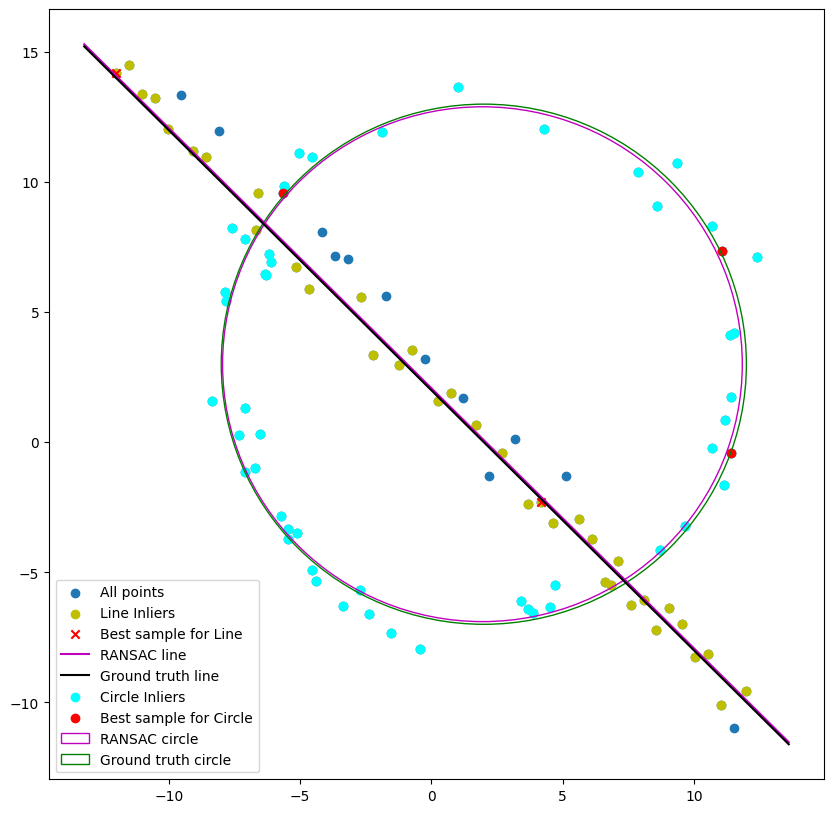

In [256]:
fig, ax = plt.subplots(1,1, figsize=(10,10))
ax.scatter(X[:,0],X[:,1], label='All points')
ax.scatter(X[best_inliers_line,0],X[best_inliers_line,1], color='y', label='Line Inliers')
ax.scatter(best_sample_line[:,0],best_sample_line[:,1], marker='x', color='r', label='Best sample for Line')
x_min, x_max = ax.get_xlim()
x_ = np.array([x_min, x_max])
y_ = (-best_model_line[1]*x_ + best_model_line[2])/best_model_line[1]
plt.plot(x_, y_, color='m', label='RANSAC line')
x_ = np.array([x_min, x_max])
y_ = m*x_ + b
plt.plot(x_, y_, color='black', label='Ground truth line')

ax.scatter(remaining_points[best_inliers,0],remaining_points[best_inliers,1], color='cyan', label='Circle Inliers')
ax.scatter(best_sample[:,0],best_sample[:,1], color='r', label='Best sample for Circle')
xc, yc, r_ = best_model_circle  # (center_x, center_y, radius)
circle_ransac = plt.Circle((xc,yc), r_, color='m', fill=False, label='RANSAC circle')
ax.add_patch(circle_ransac)
circle_gt = plt.Circle((x0_gt,y0_gt), r, color='g', fill=False, label='Ground truth circle')
ax.add_patch(circle_gt)

plt.legend()

### Q3